# Sprint 3 — Baseline models

    Entrena modelos baseline con muestra estratificada. No hay tuning en este sprint.

In [38]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import *
from src.io_utils import load_kick_data, save_df
from src.preprocessing import prepare_features, split_X_y

pd.set_option('display.max_columns', 120)
print('Proyecto:', PROJECT_ROOT)

from src.models import build_baseline_models, train_and_evaluate_baselines

Proyecto: c:\Users\PONCE\dp261-g1


In [39]:
train_sample = pd.read_csv(PROCESSED_DIR / 'train_sample.csv')
X_sample, y_sample = split_X_y(train_sample)
print(X_sample.shape, y_sample.mean())

(20000, 38) 0.123


Debido al desbalance de clases del problema (IsBadBuy ≈ 12.3%), la evaluación de modelos no se basará únicamente en accuracy.

Se priorizan métricas orientadas a la detección de vehículos problemáticos:

Recall: capacidad de detectar casos positivos (BadBuy)
Precision: proporción de positivos correctamente identificados
F2-score: métrica que prioriza Recall sobre Precision
ROC-AUC: capacidad discriminativa general del modelo

In [40]:
# Identificamos las columnas nuevas del Sprint 2
new_cols = [
    'PurchDayOfWeek', 'PurchMonth', 'PurchQuarter', 'PurchYear', 
    'acq_auction_margin', 'cost_to_acq_auction_avg', 
    'cost_to_current_auction_avg', 'current_auction_margin', 
    'current_vs_acq_auction_avg', 'warranty_to_cost'
]

# Definimos los dos sets de datos
cols_originales = [c for c in X_sample.columns if c not in new_cols]
cols_todas = list(X_sample.columns)

# Asignamos la configuración a cada modelo (La dieta del profesor)
model_configs = {
    'LogisticRegression':   {'cols': cols_originales}, 
    'LinearSVM':            {'cols': cols_originales}, 
    'KNN':                  {'cols': cols_originales}, 
    'DecisionTree':         {'cols': cols_todas},      
    'RandomForest':         {'cols': cols_todas},      
    'GradientBoosting':     {'cols': cols_todas},      
    'HistGradientBoosting': {'cols': cols_todas}       
}

In [41]:
models = build_baseline_models(X_sample)
results, fitted = train_and_evaluate_baselines(models, X_sample, y_sample, model_configs, save_models=True)

# Ordenar por la métrica que le importa a tu profesor (Recall y F2)
results = results.sort_values(["recall_cv_mean", "f2_cv_mean"], ascending=False)
display(results)

Evaluando Dummy_most_frequent con 38 columnas...
Evaluando LogisticRegression con 28 columnas...
Evaluando DecisionTree con 38 columnas...
Evaluando RandomForest con 38 columnas...
Evaluando LinearSVM con 28 columnas...
Evaluando KNN con 28 columnas...
Evaluando GradientBoosting con 38 columnas...
Evaluando HistGradientBoosting con 38 columnas...


,model,fit_time_mean,accuracy_cv_mean,accuracy_cv_std,accuracy_train_mean,accuracy_gap,precision_cv_mean,precision_cv_std,precision_train_mean,precision_gap,recall_cv_mean,recall_cv_std,recall_train_mean,recall_gap,f1_cv_mean,f1_cv_std,f1_train_mean,f1_gap,f05_cv_mean,f05_cv_std,f05_train_mean,f05_gap,f2_cv_mean,f2_cv_std,f2_train_mean,f2_gap,roc_auc_cv_mean,roc_auc_cv_std,roc_auc_train_mean,roc_auc_gap,average_precision_cv_mean,average_precision_cv_std,average_precision_train_mean,average_precision_gap,status,feature_set,n_features,seconds_total,model_path,error
2,DecisionTree,1.876519,0.82225,0.006971,1.000000,0.177750,0.305497,0.018620,1.000000,0.694503,0.347967,0.013869,1.000000,0.652033,0.325238,0.015836,1.000000,0.674762,0.313077,0.017506,1.000000,0.686923,0.338472,0.014418,1.000000,0.661528,0.618368,0.009128,1.000000,0.381632,0.186710,0.008531,1.000000,0.813290,ok,extended,38.0,10.7,c:\Users\PONCE\dp261-g1\models\baseline_Decisi...,NaN
6,GradientBoosting,8.583468,0.90145,0.003076,0.905738,0.004288,0.836724,0.033475,0.888160,0.051436,0.246748,0.018432,0.267276,0.020528,0.380922,0.024881,0.410856,0.029934,0.565646,0.030100,0.606330,0.040684,0.287207,0.020633,0.310707,0.023501,0.760120,0.014057,0.811152,0.051031,0.467894,0.025497,0.551544,0.083650,ok,extended,38.0,44.4,c:\Users\PONCE\dp261-g1\models\baseline_Gradie...,NaN
7,HistGradientBoosting,0.505993,0.90210,0.002327,0.908862,0.006762,0.870166,0.026025,0.937089,0.066924,0.239837,0.015479,0.277642,0.037805,0.375832,0.020427,0.428301,0.052469,0.569916,0.023483,0.635162,0.065247,0.280418,0.017232,0.323101,0.042683,0.760755,0.014343,0.910077,0.149322,0.471401,0.024301,0.721738,0.250338,ok,extended,38.0,5.0,c:\Users\PONCE\dp261-g1\models\baseline_HistGr...,NaN
3,RandomForest,4.606324,0.90195,0.002605,0.999987,0.098037,0.886383,0.030830,1.000000,0.113617,0.232520,0.015243,0.999898,0.767378,0.368274,0.021290,0.999949,0.631675,0.567020,0.026791,0.999980,0.432960,0.272730,0.017245,0.999919,0.727189,0.749066,0.019276,1.000000,0.250934,0.455572,0.027195,1.000000,0.544428,ok,extended,38.0,26.0,c:\Users\PONCE\dp261-g1\models\baseline_Random...,NaN
0,Dummy_most_frequent,0.249222,0.87700,0.000000,0.877000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.500000,0.000000,0.123000,0.000000,0.123000,0.000000,ok,extended,38.0,2.4,c:\Users\PONCE\dp261-g1\models\baseline_Dummy_...,NaN
1,LogisticRegression,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,error,NaN,NaN,0.0,NaN,\nAll the 5 fits failed.\nIt is very likely th...
4,LinearSVM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,error,NaN,NaN,0.1,NaN,\nAll the 5 fits failed.\nIt is very likely th...
5,KNN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,error,NaN,NaN,0.1,NaN,\nAll the 5 fits failed.\nIt is very likely th...


In [42]:
display(results)
results.to_csv(REPORTS_DIR / 'baseline_cv_results.csv', index=False)

,model,fit_time_mean,accuracy_cv_mean,accuracy_cv_std,accuracy_train_mean,accuracy_gap,precision_cv_mean,precision_cv_std,precision_train_mean,precision_gap,recall_cv_mean,recall_cv_std,recall_train_mean,recall_gap,f1_cv_mean,f1_cv_std,f1_train_mean,f1_gap,f05_cv_mean,f05_cv_std,f05_train_mean,f05_gap,f2_cv_mean,f2_cv_std,f2_train_mean,f2_gap,roc_auc_cv_mean,roc_auc_cv_std,roc_auc_train_mean,roc_auc_gap,average_precision_cv_mean,average_precision_cv_std,average_precision_train_mean,average_precision_gap,status,feature_set,n_features,seconds_total,model_path,error
2,DecisionTree,1.876519,0.82225,0.006971,1.000000,0.177750,0.305497,0.018620,1.000000,0.694503,0.347967,0.013869,1.000000,0.652033,0.325238,0.015836,1.000000,0.674762,0.313077,0.017506,1.000000,0.686923,0.338472,0.014418,1.000000,0.661528,0.618368,0.009128,1.000000,0.381632,0.186710,0.008531,1.000000,0.813290,ok,extended,38.0,10.7,c:\Users\PONCE\dp261-g1\models\baseline_Decisi...,NaN
6,GradientBoosting,8.583468,0.90145,0.003076,0.905738,0.004288,0.836724,0.033475,0.888160,0.051436,0.246748,0.018432,0.267276,0.020528,0.380922,0.024881,0.410856,0.029934,0.565646,0.030100,0.606330,0.040684,0.287207,0.020633,0.310707,0.023501,0.760120,0.014057,0.811152,0.051031,0.467894,0.025497,0.551544,0.083650,ok,extended,38.0,44.4,c:\Users\PONCE\dp261-g1\models\baseline_Gradie...,NaN
7,HistGradientBoosting,0.505993,0.90210,0.002327,0.908862,0.006762,0.870166,0.026025,0.937089,0.066924,0.239837,0.015479,0.277642,0.037805,0.375832,0.020427,0.428301,0.052469,0.569916,0.023483,0.635162,0.065247,0.280418,0.017232,0.323101,0.042683,0.760755,0.014343,0.910077,0.149322,0.471401,0.024301,0.721738,0.250338,ok,extended,38.0,5.0,c:\Users\PONCE\dp261-g1\models\baseline_HistGr...,NaN
3,RandomForest,4.606324,0.90195,0.002605,0.999987,0.098037,0.886383,0.030830,1.000000,0.113617,0.232520,0.015243,0.999898,0.767378,0.368274,0.021290,0.999949,0.631675,0.567020,0.026791,0.999980,0.432960,0.272730,0.017245,0.999919,0.727189,0.749066,0.019276,1.000000,0.250934,0.455572,0.027195,1.000000,0.544428,ok,extended,38.0,26.0,c:\Users\PONCE\dp261-g1\models\baseline_Random...,NaN
0,Dummy_most_frequent,0.249222,0.87700,0.000000,0.877000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.500000,0.000000,0.123000,0.000000,0.123000,0.000000,ok,extended,38.0,2.4,c:\Users\PONCE\dp261-g1\models\baseline_Dummy_...,NaN
1,LogisticRegression,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,error,NaN,NaN,0.0,NaN,\nAll the 5 fits failed.\nIt is very likely th...
4,LinearSVM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,error,NaN,NaN,0.1,NaN,\nAll the 5 fits failed.\nIt is very likely th...
5,KNN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,error,NaN,NaN,0.1,NaN,\nAll the 5 fits failed.\nIt is very likely th...


In [43]:
overfit_cols = [
    'model',
    'recall_gap',
    'precision_gap',
    'roc_auc_gap'
]

display(
    results[overfit_cols]
    .sort_values('recall_gap', ascending=False)
)

,model,recall_gap,precision_gap,roc_auc_gap
3,RandomForest,0.767378,0.113617,0.250934
2,DecisionTree,0.652033,0.694503,0.381632
7,HistGradientBoosting,0.037805,0.066924,0.149322
6,GradientBoosting,0.020528,0.051436,0.051031
0,Dummy_most_frequent,0.000000,0.000000,0.000000
1,LogisticRegression,NaN,NaN,NaN
4,LinearSVM,NaN,NaN,NaN
5,KNN,NaN,NaN,NaN


C:\Users\PONCE\AppData\Local\Temp\ipykernel_2832\1774591492.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


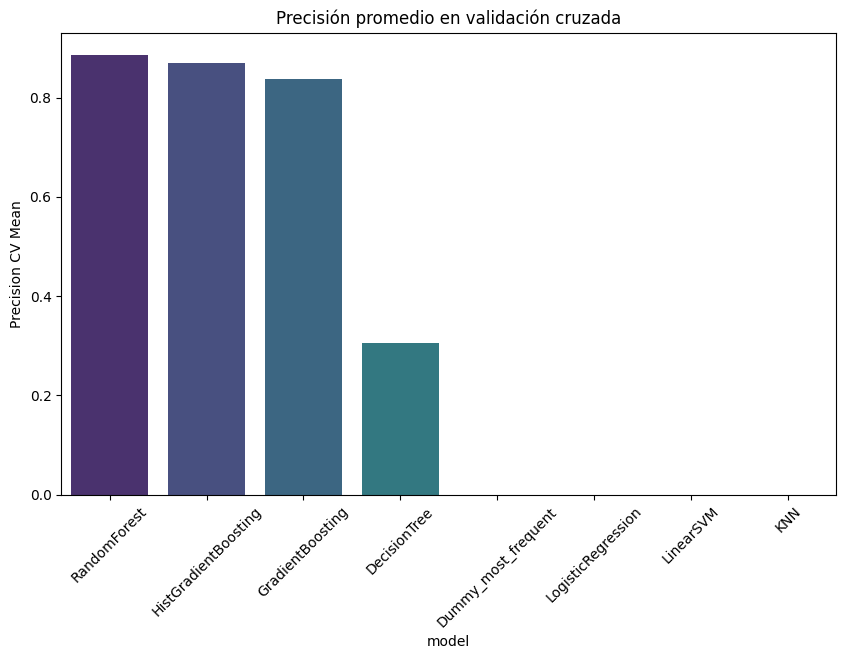

In [48]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results.sort_values('precision_cv_mean', ascending=False), # Ordenado para mejor lectura
    x='model',
    y='precision_cv_mean',
    palette='viridis' # Un color distinto para diferenciarlo del Recall
)

plt.xticks(rotation=45)
plt.title('Precisión promedio en validación cruzada')
plt.ylabel('Precision CV Mean')

plt.show()

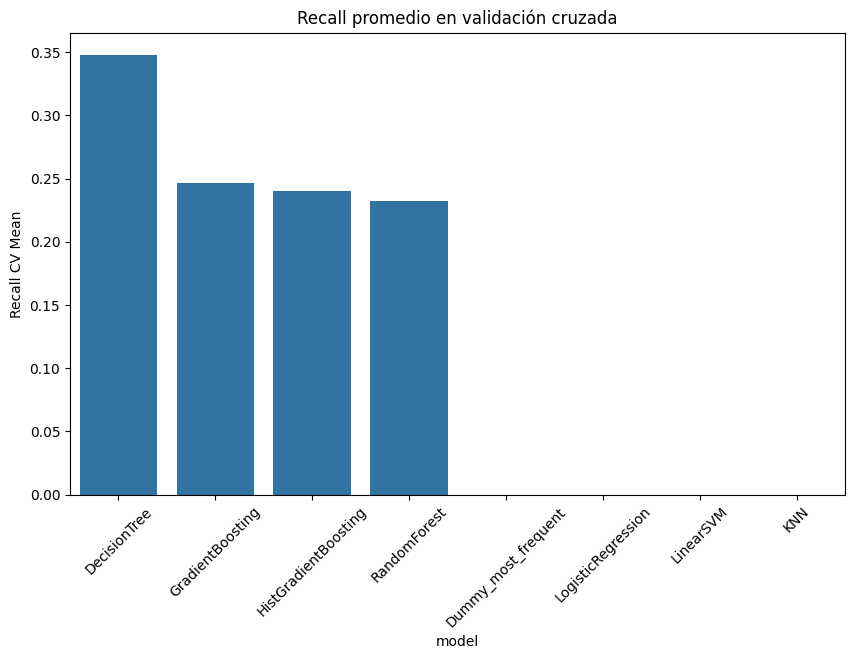

In [44]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results,
    x='model',
    y='recall_cv_mean'
)

plt.xticks(rotation=45)
plt.title('Recall promedio en validación cruzada')
plt.ylabel('Recall CV Mean')

plt.show()

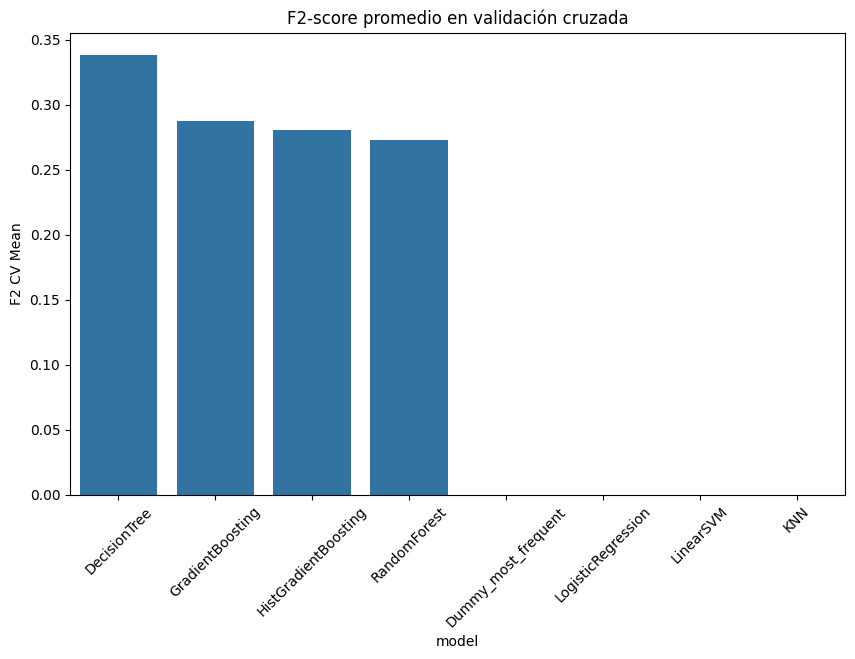

In [45]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results,
    x='model',
    y='f2_cv_mean'
)

plt.xticks(rotation=45)
plt.title('F2-score promedio en validación cruzada')
plt.ylabel('F2 CV Mean')

plt.show()